In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline

In [2]:
def plot_markov():
    plt.figure(figsize=(4, 3))
    plt.plot([0, 10], [0, 0], lw=2, color='tab:blue')
    plt.plot([10, 25], [1, 1], lw=2, color='tab:blue', label='I(x ≥ 10)')
    plt.plot([10, 10], [0, 1], lw=2, color='tab:blue', ls=':')
    plt.plot([0, 25], [0, 2.5], lw=2, color='tab:orange', label='x/10')
    plt.legend(fontsize=10)
    plt.xlabel('x')
    plt.title(r'Markov: Bounding P(X ≥ 10)', size=11);

In [3]:
def plot_chebyshev():
    plt.figure(figsize=(4, 3))
    plt.plot([-10, 10], [0, 0], lw=2, color='tab:blue')
    plt.plot([-25, -10], [1, 1], lw=2, color='tab:blue')
    plt.plot([10, 10], [0, 1], lw=2, color='tab:blue', ls=':')
    plt.plot([-10, -10], [0, 1], lw=2, color='tab:blue', ls=':')
    plt.plot([10, 25], [1, 1], lw=2, color='tab:blue', label='I(|d| ≥ 10)')
    x = np.arange(-25, 25, 0.1)
    plt.plot(x, (x/10)**2, lw=2, color='tab:orange', label='$d^2$/10')
    plt.legend(fontsize=10)
    plt.xlabel('d')
    plt.title(r'Chebyshev: Bounding P(|D| ≥ 10) for D = X-µ', size=11);

In [4]:
def plot_normal_density_bound():
    plt.figure(figsize=(4, 3))
    plt.plot([-4, 3], [0, 0], lw=2, color='tab:blue', alpha=0.5)
    plt.plot([3, 8], [1, 1], lw=2, color='tab:blue', label='I(x ≥ 3)')
    plt.plot([3, 3], [0, 1], lw=2, color='tab:blue', ls=':')
    plt.plot([3, 8], [1, 8/3], lw=2, color='tab:orange', label='x/3')
    plt.plot([-4, 3], [0, 0], lw=2, color='tab:orange', zorder=1)
    plt.legend(fontsize=10)
    plt.xlabel('x')
    plt.title(r'Standard Normal: Bounding P(Z ≥ 3)', size=11);

# Lecture 21: Concentration Inequalities

**Data 145, Spring 2026: Evidence and Uncertainty**

**Instructors:** Ani Adhikari, William Fithian

---
Please run all the code cells above before reading.

---
## 0. Introduction
In this final month of classes, each week contains its own set of topics that are not necessarily well connected to those in the previous week. We are aiming to give you a quick look at a number of topics you will encounter as you go further in machine learning and AI.

First up was multiple testing last week. This week we will study some probability facts that are commonly used in ML, AI, and inference, but are not always covered in our probability classes. Some of these facts will form a bridge to multiple regression next week.

In this lecture we examine tail bounds, with a specific goal. Suppose we have a process that is based on a random sample and generates a random numerical value, such as an empirical risk. Suppose also that as the sample size increases, the generated value converges to a target. For example, the empirical risk converges to the expected loss. 

There will typically be a largest acceptable deviation from this target, and we will typically want to control the chance of deviations that are unacceptably large. To do this, we must understand the tails of the distribution of our random quantity.

Frequently, calculating or even approximating the probabilities in the tail will be intractable. And frequently we won't need the exact values or even get close. We will just need to ensure that the tail probability is below our tolerance for large errors. In other words, we want upper bounds on the tail probabilities.

Such bounds can help us address questions such as:
- Is the tail probability less than one in a million?
- How large should my sample be so I can ensure that the tail probability will be less than one in a million?
- How fast will my random quantity of interest converge to its target value?

### Concentration 
If upper bounds on the tails are small, then we have a way of identifying where the bulk of the probability is supported. That is, we know where the probability is *concentrated*. That is why tail bounds are sometimes called **concentration inequalities**.

### Normal Tails
Many random quantities of interest to us are random sample sums or averages to which the Central Limit Theorem applies. If the sample size is large, in principle the CLT tells us the tail probabilities via the normal cumulative distribution function (cdf). But as you know, this function has no closed form other than as an integral of the normal density. This is an obstacle to working with it analytically, for example to identify a sample size large enough to control the probability in the tails. 

So even when we know a random variable is approximately normally distributed, we might still have to resort to bounds on the probabilities of the tails. Almost every section below ends with a bound applied to a standard normal tail. By scaling, the bounds can be modified for other normal distributions. Some basics:
- The standard normal density is $\phi(z) = \displaystyle \frac{1}{\sqrt{2 \pi}}e^{-\frac{1}{2}z^2}$ for all $z$.
- If $X$ has the normal $(0, \sigma^2)$ distribution, then $X = \sigma Z$ where $Z$ is standard normal.

----
## 1. Review: Markov and Chebyshev Bounds
We will start with a rapid reveiw of familiar tail bounds.

Let $X \ge 0$ have mean $\mu$. Then [Markov's inequality](https://data140.org/textbook/content/chapter-12/bounds/#markovs-inequality) says
$$
P(X \ge t) ~ \le ~ \frac{\mu}{t}
$$
This is proved by [bounding the indicator](https://data140.org/textbook/content/chapter-12/bounds/#monotonicity) function by a linear function.

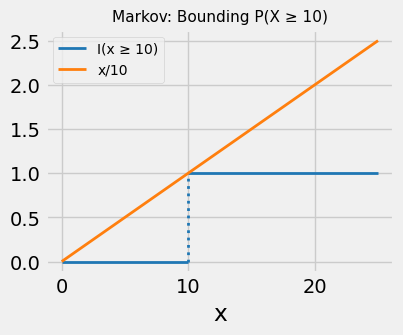

In [5]:
plot_markov()

Now let $X$ be any random variable with mean $\mu$ and variance $\sigma^2$. Bounding an indicator by a quadratic function (or applying Markov's inequality appropriately) gives us [Chebyshev's inequality](https://data140.org/textbook/content/chapter-12/bounds/#monotonicity):
$$
P(\vert X - \mu \vert \ge t) ~ \le ~ \frac{\sigma^2}{t^2}
$$

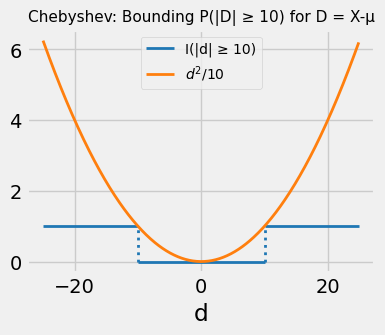

In [6]:
plot_chebyshev()

For the right tail, in general Chebyshev's bound is the same. For $t > 0$,
$$
P(X - \mu \ge t) ~ \le ~ \frac{\sigma^2}{t^2}
$$
If the distribution of $X$ is **symmetric** about $\mu$ then we can do better for the single tail:
$$
P(X - \mu \ge t) ~ \le ~ \frac{\sigma^2}{2t^2}
$$
**Application to the standard normal:** For the standard normal, this becomes
$$
P(Z > z) ~ \le ~ \frac{1}{2z^2}, ~~ z > 0
$$

---

## 2. Review: Chernoff Bound
We will now revisit Chernoff's bound, which starts with an application of Markov's bound.

For $s > 0$, $e^{sx}$ is a positive increasing function of $x$. Assume the moment generating function $M_X(s) = E(e^{sX})$ is finite at $s$. Then
$$
P(X \ge t) ~ = ~ P(e^{sX} > e^{st}) ~ \le ~ E(e^{sX})e^{-st}
$$
by Markov's inequality.

#### "Below exponential" tails
Fix $s$ and think of the bound as a function of $t$. For fixed $s$, the value of the moment generating function $M_X(s) = E(e^{sX})$ is a fixed positive number. The calculation above shows that if the moment generating function is finite at some $s > 0$, the right tail of the distribution of $X$ decreases faster than an exponential.

An analogous statement can be made for the left tail provided the mgf exists at some $s < 0$.

#### Optimized Chernoff bound
For a bound for fixed $t$, Chernoff optimizes over all $s > 0$:
$$
P(X \ge t)  ~ \le ~ \underset{\substack{s > 0}}{\inf}M_X(s)e^{-st}
$$
This typically turns into a calculus minimization problem, which is made easier by taking the $\log$ of the bound. Since the $\log$ is an increasing function, the value of $s$ that minimizes the bound is the same as the value of $s$ that minimizes the $\log$ of the bound.

**Application to the standard normal:** We carried out this process in a [Data 140 example](https://data140.org/textbook/content/chapter-19/chernoff-bound/#application-to-the-normal-distribution) to get the optimized Chernoff bound for $P(X - \mu > t)$ when $X$ has the normal $(\mu, \sigma^2)$ distribution. In $X$ is the standard normal $Z$, this bound for the right tail is
$$
P(Z > z) ~ \le ~ e^{-\frac{1}{2}z^2}, ~~ z > 0
$$
This is much smaller than Chebyshev's bound on the same tail.

---
## 3. The Bounds and the CLT
We are going to want to apply the bounds to the empirical risk which is the average loss based on our sample. As a first step, we will apply the Chebyshev and Chernoff bounds to the right tails of the mean of an i.i.d. sample.

Let $X_1, X_2, \ldots, X_n$ be i.i.d. with mean $\mu$ and variance $\sigma^2$, and let $\bar{X} = \displaystyle \frac{1}{n} \sum_{i=1}^n X_i$. Then the Central Limit Theorem says $(\bar{X} - \mu)/(\sigma/\sqrt{n})$ is approximately standard normal if $n$ is large. In that case
$$
P(\vert \bar{X} - \mu \vert > \epsilon) ~ = ~ P\left(\vert \frac{\bar{X} - \mu}{\sigma/\sqrt{n}} \vert > \frac{\epsilon}{\sigma/\sqrt{n}} \right)
~ \approx ~ P(\vert Z \vert > \sqrt{n}\epsilon/{\sigma}) ~ = ~ 2P(Z > \sqrt{n}\epsilon/{\sigma})
$$

This can be bounded by:

- Chebyshev: $\displaystyle \frac{\sigma^2}{n\epsilon^2}$
- Chernoff: $\displaystyle 2\exp\left(-\frac{n\epsilon^2}{2\sigma^2}\right)$

If $X_1, X_2, \ldots, X_n$ are i.i.d. Bernoulli $(1/2)$, $\bar{X}$ is a binomial proportion with $\mu = 1/2$ and $\sigma^2 = 1/4n$. The bounds on $P(\vert \bar{X} - 1/2 \vert > \epsilon)$ become:

- Chebyshev: $\displaystyle \frac{1}{4n\epsilon^2}$
- Chernoff: $\displaystyle 2\exp(-2n\epsilon^2)$

Clearly the Chernoff bound is better. We will return to it later in the lecture. For now, note that once we have fixed $\epsilon$, the largest error we are prepared to accept, we can easily use Chernoff's bound to figure out how large our sample has to be so that the chance of the tail is below our tolerance threshold. 

---
## 4. Mills Inequality

Even in the case of the normal, applying the bound took some work. But for the normal there is a much simpler bound that can beat Chernoff and requires no moment generating functions or minimization. Prof. Adhikari doesn't know if it has a formal name. For the purposes of this class we will refer to it as the normal density bound.

#### Normal density bound
Let $Z$ be standard normal with density $\phi$ and cdf $\Phi$. Then for $z > 0$,
$$
P(Z > z) ~ = ~ 1 - ~ \Phi(z) ~ \le ~ \frac{1}{z}\phi(z)
$$

As with the earlier bounds, this bound is derived by identifying a useful function whose graph is at least as high as that of the indicator of the tail. In the figure below, both functions have value $0$ to the left of the edge of the tail.

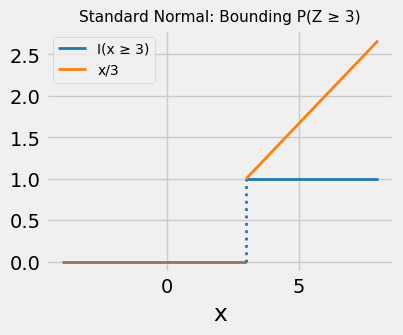

In [7]:
plot_normal_density_bound()

**Proof of the normal density bound**
$$
\begin{align*}
P(Z > z) &= \int_z^\infty \phi(x)dx \\
&\le \int_z^\infty \frac{x}{z} \phi(x)dx \\
&= \frac{1}{z}\cdot\frac{1}{\sqrt{2\pi}}\int_z^\infty xe^{-\frac{1}{2}x^2}dx \\
&= \frac{1}{z}\cdot\frac{1}{\sqrt{2\pi}} \left[ -e^{-\frac{1}{2}x^2} \right]_z^\infty \\
&= \frac{1}{z}\cdot\frac{1}{\sqrt{2\pi}}e^{-\frac{1}{2}z^2} \\
&= \frac{1}{z}\phi(z)
\end{align*}
$$

This is Chernoff's bound divided by the edge of the tail (and by $\sqrt{2\pi}$). The figure below shows how good it is. The green curve is the standard normal tail starting at 1.5, which just gets away from the center of the distribution.

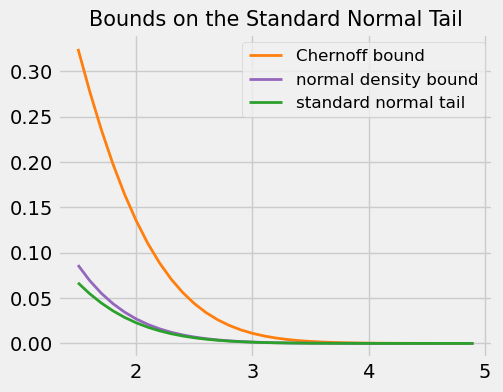

In [8]:
z = np.arange(1.5, 5, 0.1)
normal = 1 - stats.norm.cdf(z)
density_bound = stats.norm.pdf(z)/z
chernoff_bound = np.e**(-0.5*(z**2))
plt.figure(figsize=(5,4))
plt.plot(z, chernoff_bound, color='tab:orange', lw=2, label='Chernoff bound')
plt.plot(z, density_bound, color='tab:purple', lw=2, label='normal density bound')
plt.plot(z, normal, color='tab:green', lw=2, label='standard normal tail')
plt.legend(fontsize=12)
plt.title('Bounds on the Standard Normal Tail', size=15);

Chernoff's bound does well for tails that are far away from the center. It's not bad even at only 2.5 SDs above the mean. Often, it's good enough for the error control that we need.

### Mills Inequality
This is the normal density bound applied to both tails. By the symmetry of the standard normal density,
$$
P(\vert Z \vert > z ) ~ \le ~ 2 \cdot \frac{1}{z}\phi(z) ~ = ~ \sqrt{\frac{2}{\pi}}\frac{1}{z}e^{-\frac{1}{2}z^2}
$$

Sometimes we're a bit rough and just drop the constant $1/\sqrt{2\pi}$.
$$
P(Z > z) ~ \le ~ \frac{1}{z} e^{-\frac{1}{2}z^2} ~~~~~~~~~~ P(|Z| > z) ~ \le ~ \frac{2}{z} e^{-\frac{1}{2}z^2}
$$

---
## 5. Moving Away from Identical Distributions: Hoeffding's Inequality
In this class, we have almost always assumed our samples are i.i.d. We will now start to move away from that condition. Specifically, we will relax the condition that the sampled values are identically distributed. But we will continue to assume independent.

Hoeffding's bounds are on the tails of a sample sum. It assumes the random variables in the sample are bounded and independent. They are not assumed to be identically distributed.

#### Hoeffding's inequalities
Let $t > 0$. Let $X_i \in [a_i, b_i]$ be independent and let $S_n = \sum_{i=1}^n X_i$. Hoeffding's inequality is the right tail bound:
$$
P(S_n - E(S_n) \ge t) ~ \le ~ \exp \left( \frac{-2t^2}{\sum_{i=1}^n (b_i - a_i)^2} \right)
$$
The same bound works for the left tail:
$$
P(E(S_n) - S_n \ge t) ~ \le ~ \exp \left( \frac{-2t^2}{\sum_{i=1}^n (b_i - a_i)^2} \right)
$$
So a two-sided bound is
$$
P(\vert S_n - E(S_n) \vert \ge t) ~ \le ~ 2\exp \left( \frac{-2t^2}{\sum_{i=1}^n (b_i - a_i)^2} \right)
$$

#### Hoeffding applied to a sample average
Rewriting the last inequality above for the sample average gives us
$$
\begin{align*}
P(\vert \bar{X} - E\bar{X} \vert \ge t) ~ &\le ~ 2\exp \left( \frac{-2n^2t^2}{\sum_{i=1}^n (b_i - a_i)^2} \right) \\
&= 2\exp \left( \frac{-2nt^2}{\frac{1}{n}\sum_{i=1}^n (b_i - a_i)^2} \right)
\end{align*}
$$

If $X_i \in [0, 1]$ for each $i$, then 
$$
P(\vert \bar{X} - E\bar{X} \vert \ge t) ~ \le ~ 2\exp(-2nt^2)
$$
which is the same as the Chernoff bound we got in the case where the $X_i$s were i.i.d. Bernoulli $(1/2)$. 

Note that all we are assuming is the each sampled element has values in the unit interval, not necessarily at the endpoints of that interval. The bound above works for all such variables.

Clearly, the i.i.d. Bernoulli $(1/2)$ sample has such a special role here  Hoeffding's bound applied to the mean of any independent values drawn from the unit interval is the same as that for i.i.d. Bernoulli $(1/2)$ variables. 

Here is a puzzle that should give you a sense of why this is true.

#### Puzzle for you
Show that there is a unique distribution on that has the largest variance among all distributions on $[0, 1]$, and identify that distribution.

We will derive Hoeffding's bound in the next lecture. For now, let's wrap up by describing one use of Hoeffding's inequality.

### Application: Binary Classification
Suppose we have a binary classification problem in which Observation $i$ has attributes $X_i$ and binary class $Y_i$. The predicted class based on our classifier is $f(X_i) = \hat{Y}_i$, and the $0-1$ loss function is $\ell(\hat{Y}_i, Y_i) = I(\hat{Y_i} \neq Y_i)$.

The empirical risk is 
$$
\hat{R}(f) ~ = ~ \frac{1}{n} \sum_{i=1}^n \ell(f(X_i), Y_i)
$$

If the observations are i.i.d. then $\hat{R}(f)$ is an unbiased estimator of its expectation $R(f)$. Certainly $\ell(\hat{Y}_i, Y_i) \in [0, 1]$. By Hoeffding's inequality,
$$
P(\vert \hat{R}(f) - R(f) \vert \ge \epsilon) ~ \le ~ 2\exp(-2n\epsilon^2)
$$

This bound holds regardless of the type of classifier we used, whether it was logistic regression, or k-nearest neighbors, or any other binary classifier.

---
## Coming up

That's a good place to stop this lecture. The next lecture is a collection of probability topics to fill in some holes in past preparation and get ready for a deep dive into multiple regression in the following week. Topics in the next lecture:
- A proof of Hoeffding's bound; apart from the week's worksheet, this will complete our story about concentration inequalities.
- Multivariate change of variable and some consequences including a relatively painless path to the $t$ and $F$ distributions.
- If time permits, a rapid review of multiple regression facts from the probability classes, with a focus on the residuals.